# ULA (Uniform Linear Array) DOA Estimation Tests

This notebook demonstrates DOA estimation testing with ULA arrays using **only Tri4Net components**.

Key adaptations for ULA:
- Angle range: -90° to +90° (appropriate for linear arrays)
- Array configuration: Linear elements with λ/2 spacing
- Classic DOA algorithms: MUSIC, MVDR, Beamformer
- Tri4Net signal generation and evaluation framework


## 1. Setup and Imports (Tri4Net Only)


In [32]:
import sys
sys.path.append('../src')

import numpy as np
import matplotlib.pyplot as plt
import torch
from pathlib import Path
import json
from typing import List, Dict, Tuple
import warnings
warnings.filterwarnings('ignore')
# Enable interactive matplotlib backend for Jupyter notebooks
%matplotlib widget
# Tri4Net imports ONLY
from signalgen.array_processing import ArrayConfig, ArrayModel
from signalgen.signal_generator import SignalConfig, SignalGenerator
from data.simple_controlled_generator import SimpleDatasetConfig, SimpleControlledGenerator, DOADataset

# Tri4Net classic DOA algorithms
from models.classic.music import MUSIC
from models.classic.mvdr import MVDR
from models.classic.beamformer import Beamformer

# Tri4Net evaluation
from evaluation.classic.music_evaluator import MUSICEvaluator
from evaluation.classic.mvdr_evaluator import MVDREvaluator
from evaluation.classic.beamformer_evaluator import BeamformerEvaluator

print("All Tri4Net imports successful!")
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
# Enable interactive matplotlib backend for Jupyter notebooks
%matplotlib widget

# Add the SubspaceNet src directory to Python path
sys.path.append('../../SubspaceNet/src')

# Import modules using absolute imports to avoid relative import issues
from system_model import SystemModel, SystemModelParams
from signal_creation import Samples

# # Create aliases for easier access
# SystemModel = system_model.SystemModel
# SystemModelParams = system_model.SystemModelParams
# Samples = signal_creation.Samples

# Set up matplotlib for better plots
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

print("✅ Imports successful! Ready to create signals and arrays...")


All Tri4Net imports successful!
✅ Imports successful! Ready to create signals and arrays...


## 2. ULA Configuration


In [33]:
# ULA configuration using Tri4Net ArrayConfig
ula_config = ArrayConfig(
    array_type='linear',
    num_elements=8,
    element_spacing=0.5,  # λ/2 spacing
    carrier_freq=2.45e9,
    enable_gain_phase_errors=False,  # Start with perfect array
    enable_mutual_coupling=False
)

# Create ULA array model
ula_array = ArrayModel(ula_config, seed=42)

print("ULA Configuration:")
print(f"  Array type: {ula_array.config.array_type}")
print(f"  Number of elements: {ula_array.config.num_elements}")
print(f"  Element spacing: {ula_array.config.element_spacing} wavelengths")
print(f"  Carrier frequency: {ula_array.config.carrier_freq/1e9:.2f} GHz")
print(f"  Wavelength: {ula_array.wavelength:.4f} m")
print(f"  Element positions (x): {ula_array.element_positions[:, 0]}")

# Define ULA-appropriate angle range
ula_angles = np.linspace(0, 181, 181)  # -90 to +90 degrees, 1-degree resolution
print(f"\nAngle range: {ula_angles[0]}° to {ula_angles[-1]}° ({len(ula_angles)} points)")
A = ula_array.steering_matrix(ula_angles, nominal=False)
A_nominal = ula_array.steering_matrix(ula_angles, nominal=True)


ULA Configuration:
  Array type: linear
  Number of elements: 8
  Element spacing: 0.5 wavelengths
  Carrier frequency: 2.45 GHz
  Wavelength: 0.1224 m
  Element positions (x): [-0.21428571 -0.15306122 -0.09183673 -0.03061224  0.03061224  0.09183673
  0.15306122  0.21428571]

Angle range: 0.0° to 181.0° (181 points)


## 3. ULA Array Visualization


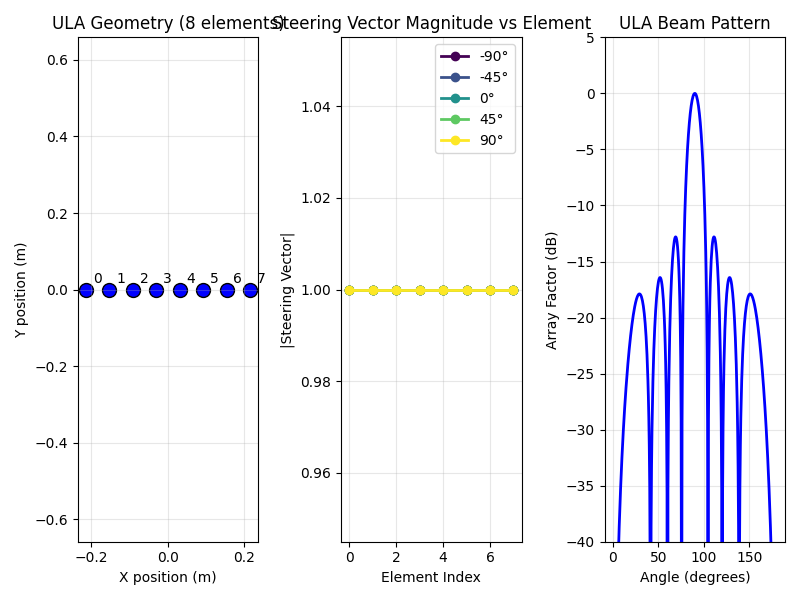

ULA Characteristics:
  Beamwidth (3dB): ~22.5°
  Angular resolution: ~45.0°
  Grating lobe-free range: ±90.0°


In [34]:
# Visualize ULA geometry and characteristics
fig, axes = plt.subplots(1, 3, figsize=(8, 6))

# 1. Array geometry
axes[0].scatter(ula_array.element_positions[:, 0], ula_array.element_positions[:, 1], 
               s=100, c='blue', marker='o', edgecolors='black')
for i, pos in enumerate(ula_array.element_positions):
    axes[0].annotate(f'{i}', (pos[0], pos[1]), xytext=(5, 5), 
                    textcoords='offset points', fontsize=10)
axes[0].set_xlabel('X position (m)')
axes[0].set_ylabel('Y position (m)')
axes[0].set_title('ULA Geometry (8 elements)')
axes[0].grid(True, alpha=0.3)
axes[0].axis('equal')

# 2. Steering vectors for different angles
test_angles = [-90, -45, 0, 45, 90]
colors = plt.cm.viridis(np.linspace(0, 1, len(test_angles)))

for angle, color in zip(test_angles, colors):
    steering_vec = ula_array.steering_vector(angle, nominal=True)
    axes[1].plot(range(len(steering_vec)), np.abs(steering_vec), 
                'o-', color=color, label=f'{angle}°', linewidth=2, markersize=6)

axes[1].set_xlabel('Element Index')
axes[1].set_ylabel('|Steering Vector|')
axes[1].set_title('Steering Vector Magnitude vs Element')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 3. Array factor (beam pattern)
angles_fine = np.linspace(0, 180, 361)
array_factors = []

for angle in angles_fine:
    steering_vec = ula_array.steering_vector(angle, nominal=True)
    # Normalize to get array factor
    array_factor = np.abs(np.sum(steering_vec))
    array_factors.append(array_factor)

array_factors = np.array(array_factors)
array_factors_db = 20 * np.log10(array_factors / np.max(array_factors))

axes[2].plot(angles_fine, array_factors_db, 'b-', linewidth=2)
axes[2].set_xlabel('Angle (degrees)')
axes[2].set_ylabel('Array Factor (dB)')
axes[2].set_title('ULA Beam Pattern')
axes[2].grid(True, alpha=0.3)
axes[2].set_ylim([-40, 5])

plt.tight_layout()
plt.show()

print("ULA Characteristics:")
print(f"  Beamwidth (3dB): ~{180/ula_array.config.num_elements:.1f}°")
print(f"  Angular resolution: ~{2*180/ula_array.config.num_elements:.1f}°")
print(f"  Grating lobe-free range: ±{np.degrees(np.arcsin(1/(2*ula_array.config.element_spacing))):.1f}°")


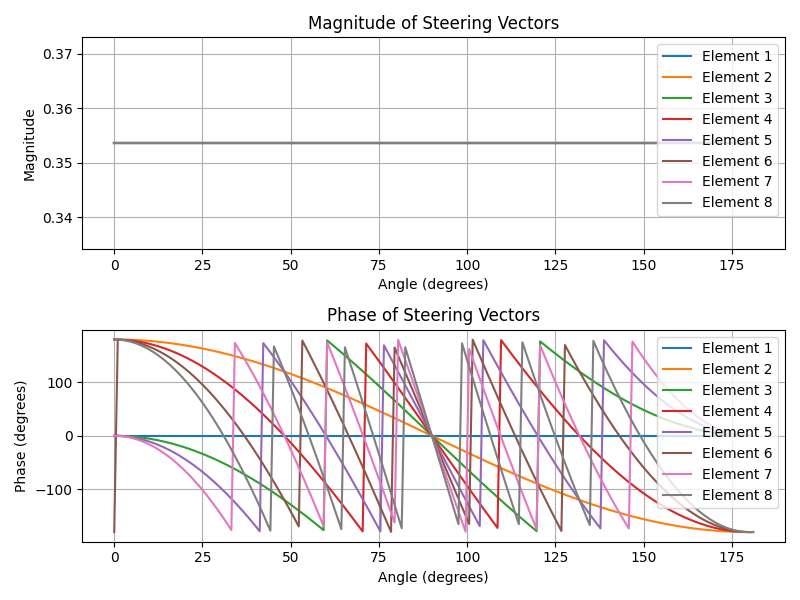

In [35]:
# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6))

# Plot magnitude of steering vectors
for i in range(A.shape[0]):
    ax1.plot(ula_angles, np.abs(A[i, :]), label=f'Element {i+1}')
ax1.set_title('Magnitude of Steering Vectors')
ax1.set_xlabel('Angle (degrees)')
ax1.set_ylabel('Magnitude')
ax1.grid(True)
ax1.legend()

# Plot phase of steering vectors
for i in range(A.shape[0]):
    ax2.plot(ula_angles, np.angle(A[i, :], deg=True), label=f'Element {i+1}')
ax2.set_title('Phase of Steering Vectors')
ax2.set_xlabel('Angle (degrees)')
ax2.set_ylabel('Phase (degrees)')
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

In [36]:
# # Get conjugate transpose of steering vectors
# AH = A_nominal.conj().T

# # Optimized calculation of 2D beampattern
# # Instead of nested loops, we use matrix operations
# N = A.shape[0]  # number of elements

# # Calculate denominator term (normalization factor)
# # This is the same for all angles: aH @ a
# denom = np.diag(AH @ A)  # shape: (K,)

# # Calculate numerator term
# # For each steering direction, calculate the response to all possible signal directions
# BP = np.zeros((len(ula_angles), len(ula_angles)), dtype=complex)

# for i in range(len(ula_angles)):
#     # Get steering vector for this direction
#     x = A_nominal[:, i:i+1]  # shape: (N, 1)
#     xH = x.conj().T  # shape: (1, N)
    
#     # Calculate covariance matrix for this steering direction
#     R = x @ xH  # shape: (N, N)
    
#     # Calculate response to all possible signal directions
#     # This is equivalent to: aH[j] @ R @ a[j] for each j
#     # We can do this for all j at once using matrix multiplication
#     BP[i, :] = np.diag(AH @ R @ A_nominal) / (denom * R.trace())

# # Convert to dB and clip
# # Handle zero and negative values properly
# BP_real = np.real(BP)
# BP_real[BP_real <= 0] = 1e-10  # Replace zero/negative values with small positive number
# BP_db = 10 * np.log10(BP_real)
# min_db = -15
# BP_db[BP_db < min_db] = min_db
# # Create figure
# fig = plt.figure(figsize=(10, 6))
# ax = fig.add_subplot(111)

# # Plot 2D beampattern
# im = ax.contourf(ula_angles, ula_angles, BP_db, 20, cmap='jet')
# plt.colorbar(im, label='Magnitude [dB]')

# # Set labels and title
# ax.set_xlabel('Signal Direction [degrees]')
# ax.set_ylabel('Steering Direction [degrees]')
# nominal = True
# title = 'Nominal 2D Beampattern' if nominal else '2D Beampattern with Mismatches'
# ax.set_title(title)
# plt.show()


In [37]:
# def plot_vertical_cut_and_calculate_3db_width(angles, BP_db, target_angle, title_suffix=""):
#     """
#     Plot vertical cut of beampattern at specified angle and calculate 3dB width.
    
#     Parameters:
#     angles: array of angles
#     BP_db: 2D beampattern array
#     target_angle: angle to plot vertical cut (degrees)
#     title_suffix: additional text for title
#     """
#     # Find closest angle index
#     angle_idx = np.argmin(np.abs(angles - target_angle))
#     actual_angle = angles[angle_idx]
    
#     # Extract vertical cut (steering direction vs magnitude)
#     vertical_cut = BP_db[:, angle_idx]
    
#     # Find peak
#     peak_idx = np.argmax(vertical_cut)
#     peak_angle = angles[peak_idx]
#     peak_magnitude = vertical_cut[peak_idx]
    
#     # Calculate 3dB down point
#     threshold_3db = peak_magnitude - 3
    
#     # Find points where magnitude crosses 3dB threshold
#     # Look for crossings in both directions from peak
#     left_3db_idx = None
#     right_3db_idx = None
    
#     # Search left from peak
#     for i in range(peak_idx, -1, -1):
#         if vertical_cut[i] <= threshold_3db:
#             left_3db_idx = i
#             break
    
#     # Search right from peak
#     for i in range(peak_idx, len(vertical_cut)):
#         if vertical_cut[i] <= threshold_3db:
#             right_3db_idx = i
#             break
    
#     # Calculate 3dB width
#     if left_3db_idx is not None and right_3db_idx is not None:
#         left_angle = angles[left_3db_idx]
#         right_angle = angles[right_3db_idx]
#         width_3db = right_angle - left_angle
#     else:
#         width_3db = None
    
#     # Create plot
#     fig, ax = plt.subplots(figsize=(10, 6))
    
#     # Plot vertical cut
#     ax.plot(angles, vertical_cut, 'b-', linewidth=2, label=f'Vertical cut at {actual_angle:.1f}°')
    
#     # Mark peak
#     ax.plot(peak_angle, peak_magnitude, 'ro', markersize=8, label=f'Peak: {peak_angle:.1f}°')
    
#     # Mark 3dB points if found
#     if left_3db_idx is not None:
#         ax.plot(angles[left_3db_idx], vertical_cut[left_3db_idx], 'gs', markersize=6, 
#                 label=f'Left 3dB: {angles[left_3db_idx]:.1f}°')
#     if right_3db_idx is not None:
#         ax.plot(angles[right_3db_idx], vertical_cut[right_3db_idx], 'gs', markersize=6, 
#                 label=f'Right 3dB: {angles[right_3db_idx]:.1f}°')
    
#     # Plot 3dB threshold line
#     if width_3db is not None:
#         ax.axhline(y=threshold_3db, color='r', linestyle='--', alpha=0.7, 
#                    label=f'3dB threshold: {threshold_3db:.1f} dB')
    
#     # Add width annotation
#     if width_3db is not None:
#         ax.text(0.02, 0.98, f'3dB Width: {width_3db:.1f}°', 
#                 transform=ax.transAxes, fontsize=12, 
#                 verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
#     ax.set_xlabel('Steering Direction [degrees]')
#     ax.set_ylabel('Magnitude [dB]')
#     ax.set_title(f'Vertical Cut of Beampattern at {actual_angle:.1f}°{title_suffix}')
#     ax.grid(True, alpha=0.3)
#     ax.legend()
    
#     plt.tight_layout()
#     plt.show()
    
#     # Print results
#     print(f"Vertical cut at angle: {actual_angle:.1f}°")
#     print(f"Peak found at: {peak_angle:.1f}° (magnitude: {peak_magnitude:.1f} dB)")
#     if width_3db is not None:
#         print(f"3dB width: {width_3db:.1f}°")
#         print(f"3dB points: {angles[left_3db_idx]:.1f}° to {angles[right_3db_idx]:.1f}°")
#     else:
#         print("Could not determine 3dB width (threshold not crossed)")
    
#     return width_3db, peak_angle, peak_magnitude

# # Example usage - you can change the target_angle to any angle you want to analyze
# target_angle = 90  # degrees
# width_3db, peak_angle, peak_magnitude = plot_vertical_cut_and_calculate_3db_width(
#     ula_angles, BP_db, target_angle, " (with Mismatches)" if not nominal else " (Nominal)"
# )


## 4. ULA Test Scenarios


In [38]:
# Scenario 1: 1 main source
config_main_only = SignalConfig(
    fs=1e3,  # Sampling frequency
    T=1024,   # Number of snapshots
    num_sources=1,  # Number of sources
    frequencies=[100],  # Frequencies for each source
    main_source_power=0,  # Amplitudes for each source
    angles=[48],  # Angles for each source
)

# Scenario 2: 1 main source + 1 interference
config_main_1_interference = SignalConfig(
    fs=1e3,  # Sampling frequency
    T=1024,   # Number of snapshots
    num_sources=2,  # Number of sources
    frequencies=[100, 200],  # Frequencies for each source
    main_source_power=0,  # Amplitudes for each source
    angles=[90, 100],  # Angles for main signal and interference
    sir_db=[0],  # Signal-to-interference ratio
    use_full_bandwidth=True  # Enable full bandwidth signals
)

# Scenario 3: 1 main source + 2 interference
config_main_2_interference = SignalConfig(
    fs=1e3,  # Sampling frequency
    T=1024,   # Number of snapshots
    num_sources=3,  # Number of sources
    frequencies=[100, 200, 300],  # Frequencies for each source
    main_source_power=0,  # Amplitudes for each source
    angles=[85, 90, 95],  # Angles for main signal and interferences
    sir_db=[0, 0],  # Signal-to-interference ratios
    use_full_bandwidth=True  # Enable full bandwidth signals
)

# Scenario 4: 1 main source + 1 multipath
config_main_1_mp = SignalConfig(
    fs=1e3,  # Sampling frequency
    T=1024,   # Number of snapshots
    num_sources=1,  # Number of sources
    frequencies=[100],  # Frequencies for each source
    main_source_power=0,  # Amplitudes for each source
    angles=[48],  # Angles for each source
    enable_multipath=True  # Enable multipath capability
)

# Scenario 5: 1 main source + 2 multipath
config_main_2_mp = SignalConfig(
    fs=1e3,  # Sampling frequency
    T=1024,   # Number of snapshots
    num_sources=1,  # Number of sources
    frequencies=[100],  # Frequencies for each source
    main_source_power=0,  # Amplitudes for each source
    angles=[48],  # Angles for each source
    enable_multipath=True,  # Enable multipath capability
)

# Scenario 6: 1 main source + 1 interference + 1 multipath
config_main_1_interference_1_mp = SignalConfig(
    fs=1e3,  # Sampling frequency
    T=1024,   # Number of snapshots
    num_sources=2,  # Number of sources
    frequencies=[100, 200],  # Frequencies for each source
    main_source_power=0,  # Amplitudes for each source
    angles=[85, 90],  # Angles for main signal and interference
    sir_db=[0],  # Signal-to-interference ratio
    enable_multipath=True  # Enable multipath capability
)

In [39]:
config_main_1_interference

SignalConfig(fs=1000.0, T=1024, num_sources=2, angles=[90, 100], frequencies=[100, 200], powers=[0.0, 0.0], main_source_power=0, snr_db=None, noise_type='gaussian', sir_db=[0], bandwidth=50.0, use_full_bandwidth=True, enable_multipath=False, num_paths=1, path_delays=None, path_phases=None, path_gains=None, smr=None)

## 5. Signal Generation


In [40]:
# Initialize signal generators for all scenarios
generator_main_only = SignalGenerator(config_main_only)
generator_main_1_interference = SignalGenerator(config_main_1_interference)
generator_main_2_interference = SignalGenerator(config_main_2_interference)
generator_main_1_mp = SignalGenerator(config_main_1_mp)
generator_main_2_mp = SignalGenerator(config_main_2_mp)
generator_main_1_interference_1_mp = SignalGenerator(config_main_1_interference_1_mp)

# Generate time axis
t = generator_main_only.generate_time_axis()

# Generate source signals for all scenarios
signals_main_only = generator_main_only.generate_source_signals(t)
signals_main_1_interference = generator_main_1_interference.generate_source_signals(t)
signals_main_2_interference = generator_main_2_interference.generate_source_signals(t)

# Generate signals for multipath scenarios
signals_main_1_mp = generator_main_1_mp.generate_source_signals(t)
signals_main_2_mp = generator_main_2_mp.generate_source_signals(t)
signals_main_1_interference_1_mp = generator_main_1_interference_1_mp.generate_source_signals(t)

# Add multipath effects to multipath scenarios
signals_main_1_mp = generator_main_1_mp.add_multipath(signals_main_1_mp, t, config_main_1_mp.fs, 2.4e9, config_main_1_mp.fs/2, num_multipath_components=1)
signals_main_2_mp = generator_main_2_mp.add_multipath(signals_main_2_mp, t, config_main_2_mp.fs, 2.4e9, config_main_2_mp.fs/2, num_multipath_components=2)
signals_main_1_interference_1_mp = generator_main_1_interference_1_mp.add_multipath(signals_main_1_interference_1_mp, t, config_main_1_interference_1_mp.fs, 2.4e9, config_main_1_interference_1_mp.fs/2, num_multipath_components=1)


In [41]:
signal = signals_main_1_interference
signal_config = config_main_1_interference
# Create system model parameters object
params = SystemModelParams()
params.set_parameter("M", 2)
params.set_parameter("N", 8)
params.set_parameter("T", 1024)
params.set_parameter("signal_type", "NarrowBand")
params.set_parameter("signal_nature", "non-coherent")
params.set_parameter("snr", 10)
params.set_parameter("eta", 0)

# Create the samples object (includes system model)
samples_obj = Samples(params)
# Option 1: Specify exact DOA angles in degrees
doa_angles = [0, 5] # Angles in degrees, set to None for auto-generation

# Option 2: Auto-generate DOAs with minimum separation (set doa_angles = None)
# doa_angles = None  # This will auto-generate angles with 15° minimum separation

# Set the DOA angles
samples_obj.set_doa(doa_angles)

In [42]:
from signalgen.array_processing import ReceivedSignal
steering_matrix = ula_array.steering_matrix(signal_config.angles, nominal=True)
x = ReceivedSignal(steering_matrix, signal, signal_config.angles, signal_config)
clean_signal = x.array_signals.copy()
print(signal_config.bandwidth)
noisy_object = x.add_noise(snr_db=10, source_frequencies=signal_config.frequencies, signal_bandwidth=signal_config.bandwidth, sampling_frequency=signal_config.fs)
n_t = noisy_object.noise.copy()
noisy_signal = noisy_object.array_signals.copy()
# Signal Generation Parameters
# ============================

# Noise parameters
noise_mean = 0
noise_variance = 1

# Signal parameters
signal_mean = 0
signal_variance = 1

# Generate samples
observations, signals, steering_vectors, noise = samples_obj.samples_creation(
    noise_mean=noise_mean,
    noise_variance=noise_variance, 
    signal_mean=signal_mean,
    signal_variance=signal_variance
)
print(f'\n Observations power: {np.mean(np.abs(observations)**2, axis=1)}')

print(f'\n x(t) power: {np.mean(np.abs(noisy_signal)**2, axis=1)}')

print(f'\n Noise power: {np.mean(np.abs(noise)**2, axis=1)}')

print(f'\n n(t) power: {np.mean(np.abs(n_t)**2, axis=1)}')

print(f'\n Signal power: {np.mean(np.abs(signals)**2, axis=1)}')

print(f'\n s(t): {np.mean(np.abs(signal)**2, axis=1)}')


1000.0

 Observations power: [0.34273036 0.37172603 0.36202021 0.35765532 0.35159761 0.34794949
 0.35793991 0.35821546]

 x(t) power: [0.35260121 0.34342215 0.32750687 0.33845372 0.36001841 0.34186148
 0.34940749 0.34916995]

 Noise power: [0.09561512 0.10839102 0.10049294 0.09856281 0.102817   0.09930174
 0.10365193 0.09994131]

 n(t) power: [0.09584802 0.09763192 0.10269158 0.10000738 0.10723031 0.09832452
 0.10102202 0.09740087]

 Signal power: [0.98483143 1.03350445]

 s(t): [1. 1.]


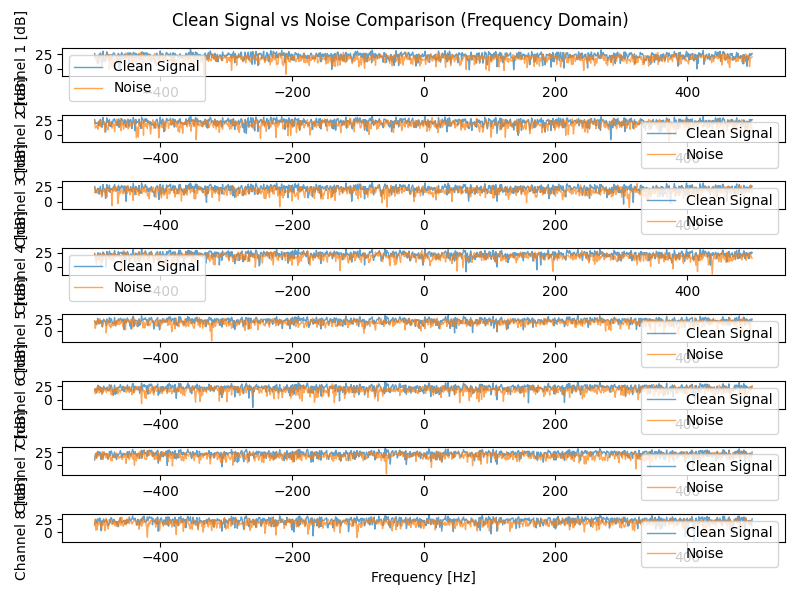

In [43]:
# Create figure with subplots for each channel
fig, axes = plt.subplots(noisy_signal.shape[0], 1, figsize=(8, 6))
fig.suptitle('Clean Signal vs Noise Comparison (Frequency Domain)')

# Plot each channel
for i in range(noisy_signal.shape[0]):
    # Compute FFT for clean signal and noise
    clean_fft = np.fft.fftshift(np.fft.fft(clean_signal[i]))
    noise_fft = np.fft.fftshift(np.fft.fft(noise[i]))
    
    # Create frequency axis
    freq = np.fft.fftshift(np.fft.fftfreq(len(clean_signal[i]), 1/signal_config.fs))
    
    # Plot magnitude spectrum in dB
    clean_magnitude_db = 20 * np.log10(np.abs(clean_fft) + 1e-12)
    noise_magnitude_db = 20 * np.log10(np.abs(noise_fft) + 1e-12)
    
    # Plot clean signal
    axes[i].plot(freq, clean_magnitude_db, label='Clean Signal', alpha=0.7, linewidth=1)
    # Plot noise
    axes[i].plot(freq, noise_magnitude_db, label='Noise', alpha=0.7, linewidth=1)
    axes[i].set_ylabel(f'Channel {i+1} [dB]')
    axes[i].legend()
    if i == noisy_signal.shape[0]-1:  # Only show xlabel for bottom subplot
        axes[i].set_xlabel('Frequency [Hz]')

plt.tight_layout()
plt.show()


(8, 8)
Eigenvalues:
[1.44121221 0.72819752 0.11055156 0.1083672  0.10278106 0.09638993
 0.0910424  0.08505946]

Diagonal of Covariance matrix:
[0.35273813 0.34369594 0.32777453 0.33860725 0.36030933 0.34182489
 0.34946904 0.34918221]

Trace of Covariance matrix:
(2.7636013332189813+1.00359549917328e-18j)

Main eigenvalue: 1.441212
Sum of smaller eigenvalues: 0.594192
Ratio (main/smaller): 2.425501
Ratio in dB: 3.85 dB


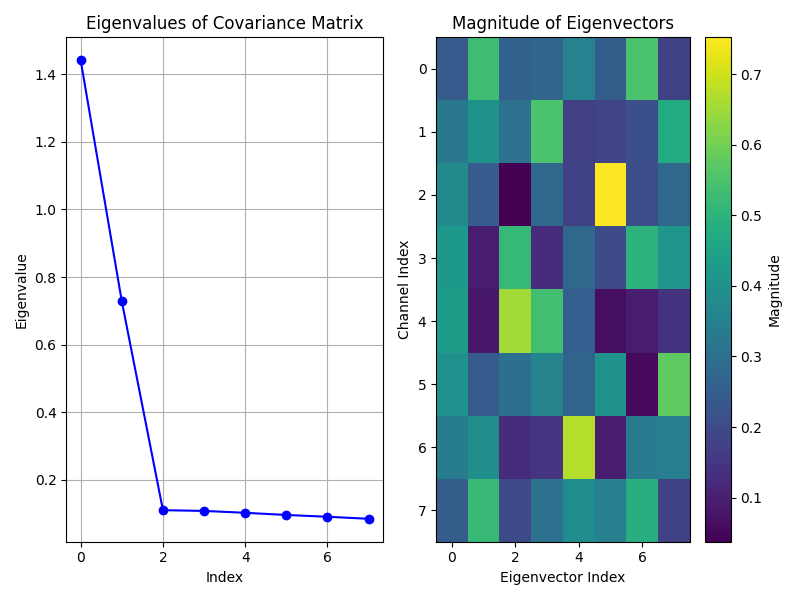

In [44]:
# Calculate covariance matrix
cov_matrix = np.cov(noisy_signal)
print(cov_matrix.shape)
# cov_matrix = cov_matrix / np.linalg.norm(cov_matrix)

# Calculate eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
# Normalize eigenvectors to unit length (orthonormal)
# eigenvectors = eigenvectors / np.linalg.norm(eigenvectors, axis=0, keepdims=True)

# Sort eigenvalues and eigenvectors in descending order
sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors[:, sorted_indices]

print("Eigenvalues:")
print(np.abs(eigenvalues))
# print("\nEigenvectors:")
# print(eigenvectors)
print('\nDiagonal of Covariance matrix:')
print((np.abs(np.diag(cov_matrix))))

print('\nTrace of Covariance matrix:')
print(np.trace(cov_matrix))

# Calculate main eigenvalue divided by sum of smaller eigenvalues and convert to dB
main_eigenvalue = np.abs(eigenvalues[0])
smaller_eigenvalues_sum = np.sum(np.abs(eigenvalues[signal_config.num_sources:]))
eigenvalue_ratio = main_eigenvalue / smaller_eigenvalues_sum
eigenvalue_ratio_db = 10 * np.log10(eigenvalue_ratio)

print(f"\nMain eigenvalue: {main_eigenvalue:.6f}")
print(f"Sum of smaller eigenvalues: {smaller_eigenvalues_sum:.6f}")
print(f"Ratio (main/smaller): {eigenvalue_ratio:.6f}")
print(f"Ratio in dB: {eigenvalue_ratio_db:.2f} dB")

# Plot eigenvalues
plt.figure(figsize=(8, 6))
plt.subplot(1, 2, 1)
plt.plot(eigenvalues, 'bo-')
plt.title('Eigenvalues of Covariance Matrix')
plt.xlabel('Index')
plt.ylabel('Eigenvalue')
plt.grid(True)

# Plot eigenvectors
plt.subplot(1, 2, 2)
plt.imshow(np.abs(eigenvectors), cmap='viridis', aspect='auto')
plt.title('Magnitude of Eigenvectors')
plt.xlabel('Eigenvector Index')
plt.ylabel('Channel Index')
plt.colorbar(label='Magnitude')

plt.tight_layout()
plt.show()


## 6. DOA Algorithm Testing


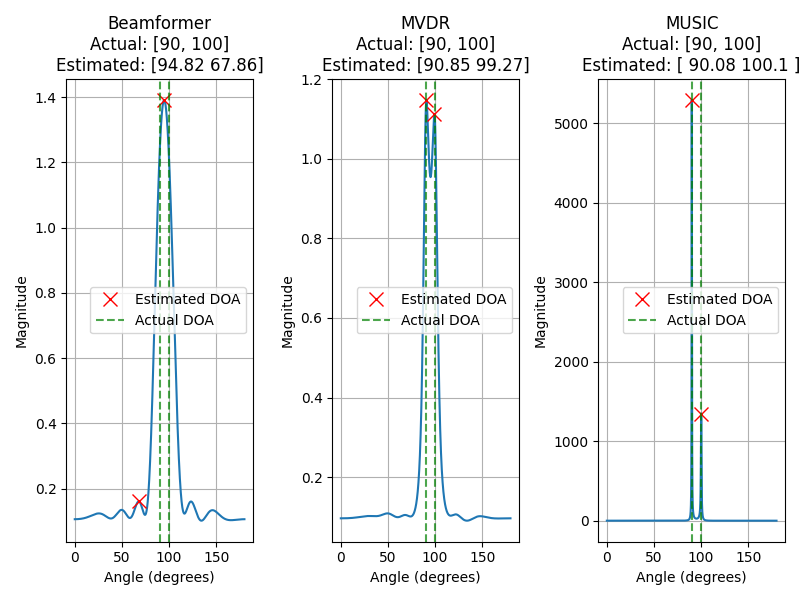

In [45]:
from models.classic import Beamformer, MVDR, MUSIC
angles = np.linspace(0, 180, 18000, endpoint=False)
A_nominal = ula_array.steering_matrix(angles, nominal=True)
# Initialize all three estimators
bart = Beamformer(ula_array, A_nominal, angles, num_sources=len(signal_config.angles))
mvdr = MVDR(ula_array, A_nominal, angles, num_sources=len(signal_config.angles))
music = MUSIC(ula_array, A_nominal, angles, num_sources=len(signal_config.angles))

# Get actual angles
actual_angles = signal_config.angles

# Create subplots for all three estimators
fig, axes = plt.subplots(1, 3, figsize=(8, 6))
estimators = [bart, mvdr, music]
estimator_names = ['Beamformer', 'MVDR', 'MUSIC']

for i, (est, name) in enumerate(zip(estimators, estimator_names)):
    # Set received data and estimate DOA
    est.set_received_data(noisy_signal)
    estimated_angles, spectrum = est.estimate_doa()
    
    # Plot the spectrum
    axes[i].plot(angles, spectrum)
    axes[i].set_title(f'{name}\nActual: {actual_angles}\nEstimated: {np.round(estimated_angles, 2)}')
    axes[i].set_xlabel('Angle (degrees)')
    axes[i].set_ylabel('Magnitude')
    axes[i].grid(True)
    
    # Plot estimated angles with X markers
    axes[i].plot(estimated_angles, spectrum[np.searchsorted(angles, estimated_angles)], 
                 'rx', markersize=10, label='Estimated DOA')
    
    # Plot actual angles with dashed lines
    for angle in actual_angles:
        axes[i].axvline(x=angle, color='g', linestyle='--', alpha=0.7, 
                       label='Actual DOA' if angle == actual_angles[0] else "")
    
    axes[i].legend()

plt.tight_layout()
plt.show()
